<a href="https://colab.research.google.com/github/Jammal1996/spotter-freight-rate-ml/blob/main/notebooks/01_freight_rate_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Connect Colab to your Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Connecting to Github

In [2]:
# Clone the repo into Colab's temporary storage
!git clone https://github.com/Jammal1996/spotter-freight-rate-ml.git
%cd spotter-freight-rate-ml

# Install dependencies
!pip install -r requirements.txt

Cloning into 'spotter-freight-rate-ml'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 34 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 1.76 MiB | 6.05 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/spotter-freight-rate-ml


In [3]:
!ls
!ls data

data  notebooks  README.md  requirements.txt  score.py
train-test.csv	validation.csv	validation-predictions-template.csv


In [4]:
import os
print("Current folder:", os.getcwd())
!ls
!ls data

Current folder: /content/spotter-freight-rate-ml
data  notebooks  README.md  requirements.txt  score.py
train-test.csv	validation.csv	validation-predictions-template.csv


In [5]:
import glob
for f in glob.glob("/content/drive/MyDrive/**/*.csv", recursive=True):
    print(f)

/content/drive/MyDrive/Machine Learning Assignment/data/validation.csv
/content/drive/MyDrive/Machine Learning Assignment/data/validation_predictions_template.csv
/content/drive/MyDrive/Machine Learning Assignment/data/train_test.csv
/content/drive/MyDrive/Machine Learning Assignment/data/december_chart_inputs.csv
/content/drive/MyDrive/Assignments/Machine Learning/Data.csv
/content/drive/MyDrive/Assignments/Machine Learning/melb_data.csv
/content/drive/MyDrive/Assignments/Machine Learning/LifeExpectancyData.csv
/content/drive/MyDrive/Assignments/Machine Learning/50_Startups.csv
/content/drive/MyDrive/Assignments/Machine Learning/loan.csv
/content/drive/MyDrive/Assignments/Machine Learning/train.csv
/content/drive/MyDrive/Assignments/Machine Learning/test.csv
/content/drive/MyDrive/Assignments/Machine Learning/Social_Network_Ads.csv
/content/drive/MyDrive/Assignments/Machine Learning/BreastCancer.csv
/content/drive/MyDrive/Assignments/Data Preprocessing/Data.csv
/content/drive/MyDrive/

Cell 1: Load data

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

DATA_DIR = "/content/drive/MyDrive/Machine Learning Assignment/data"

train = pd.read_csv(f"{DATA_DIR}/train_test.csv", parse_dates=["date"])
val = pd.read_csv(f"{DATA_DIR}/validation.csv", parse_dates=["date"])
template = pd.read_csv(f"{DATA_DIR}/validation_predictions_template.csv")

print("train", train.shape, "| val", val.shape, "| template", template.shape)
print("train dates:", train.date.min().date(), "to", train.date.max().date())
print("val dates:  ", val.date.min().date(), "to", val.date.max().date())
train.head()

train (48000, 14) | val (12000, 13) | template (12000, 2)
train dates: 2025-01-01 to 2025-10-31
val dates:   2025-11-01 to 2025-12-31


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


Cell 2: Basic quality checks

In [7]:
print("Missing values (train):\n", train.isna().sum()[lambda s: s > 0], "\n")
print("Missing values (val):\n", val.isna().sum()[lambda s: s > 0], "\n")

print("Duplicate load_ids:", train.load_id.duplicated().sum())
print("Duplicate rows (ignoring id):", train.duplicated(subset=train.columns[1:]).sum())
print("Template ids match validation ids:", set(template.load_id) == set(val.load_id))

print("\nNegative weights  train:", (train.weight < 0).sum(), " val:", (val.weight < 0).sum())
print("Same pickup/delivery city:", (train.pickup == train.delivery).sum())
print("Non-positive distance:", (train.distance <= 0).sum())

train.describe().T

Missing values (train):
 weight          300
market_index    374
dtype: int64 

Missing values (val):
 weight          165
market_index    249
dtype: int64 

Duplicate load_ids: 0
Duplicate rows (ignoring id): 0
Template ids match validation ids: True

Negative weights  train: 292  val: 145
Same pickup/delivery city: 0
Non-positive distance: 0


,count,mean,min,25%,50%,75%,max,std
pickup_lat,48000.0,35.647545,28.35765,31.98691,35.29479,39.41104,44.30296,4.315285
pickup_lon,48000.0,-90.928964,-121.69849,-98.40059,-88.08915,-83.28506,-69.5,13.482431
delivery_lat,48000.0,35.641175,28.35765,31.98691,35.29479,39.41104,44.30296,4.317199
delivery_lon,48000.0,-90.85731,-121.69849,-98.40059,-87.52871,-83.28506,-69.5,13.476589
distance,48000.0,1135.856654,70.0,550.4,953.3,1645.525,3439.8,728.564416
weight,47700.0,31028.844004,-47500.0,25800.0,31436.5,37018.0,47500.0,9391.44062
date,48000,2025-05-31 19:53:29.400000,2025-01-01 00:00:00,2025-03-18 00:00:00,2025-05-31 00:00:00,2025-08-15 00:00:00,2025-10-31 00:00:00,NaN
market_index,47626.0,1.083387,0.67639,0.94967,1.0558,1.21959,1.46778,0.168091
quote_signal,48000.0,2.062468,0.69228,1.89103,2.05575,2.221685,3.61035,0.291391
posted_rate,48000.0,2373.980682,57.22,1251.555,2030.76,3330.75,25533.0,1486.493245


Cell 3: Target distribution and outliers

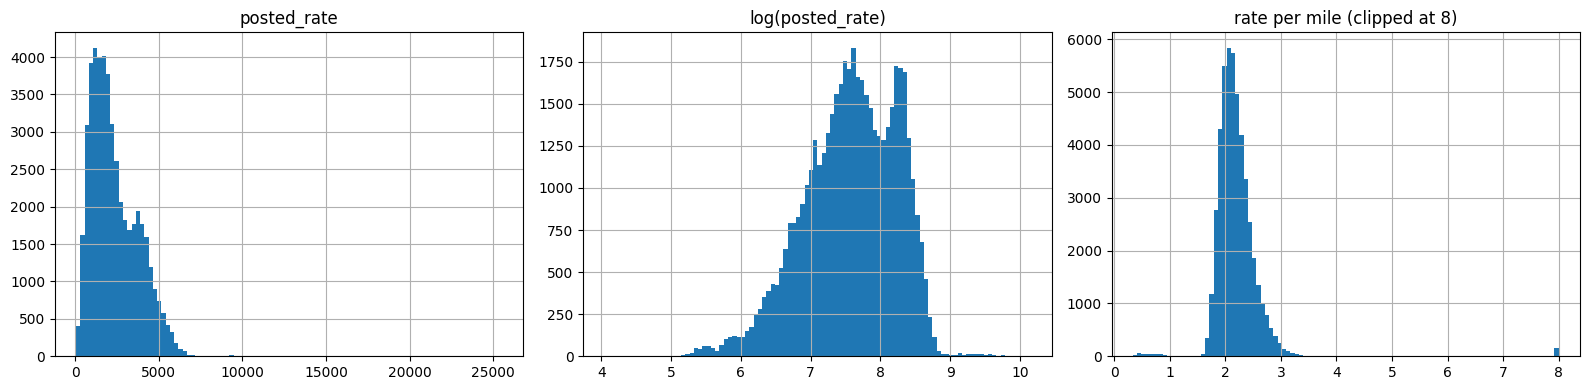

0.001     0.437364
0.010     1.673521
0.050     1.807533
0.500     2.145348
0.950     2.735925
0.990     3.176940
0.999    10.068775
Name: rpm, dtype: float64
Rows with rpm > 6: 270 | rpm < 0.8: 266


In [8]:
train["rpm"] = train.posted_rate / train.distance   # rate per mile

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
train.posted_rate.hist(bins=100, ax=ax[0]); ax[0].set_title("posted_rate")
np.log(train.posted_rate).hist(bins=100, ax=ax[1]); ax[1].set_title("log(posted_rate)")
train.rpm.clip(upper=8).hist(bins=100, ax=ax[2]); ax[2].set_title("rate per mile (clipped at 8)")
plt.tight_layout(); plt.show()

print(train.rpm.quantile([.001, .01, .05, .5, .95, .99, .999]))
print("Rows with rpm > 6:", (train.rpm > 6).sum(), "| rpm < 0.8:", (train.rpm < 0.8).sum())

Cell 4: Look at the extreme rows

In [9]:
cols = ["load_id", "pickup", "delivery", "distance", "equipment", "weight", "date", "posted_rate", "rpm"]
print("Highest rate per mile:")
display(train.sort_values("rpm", ascending=False)[cols].head(10))
print("Lowest rate per mile:")
display(train.sort_values("rpm")[cols].head(10))

# Are the extremes concentrated in short hauls?
train["dist_bin"] = pd.cut(train.distance, [0, 250, 500, 1000, 2000, 4000])
print(train.groupby("dist_bin", observed=True).rpm.describe().round(2))

Highest rate per mile:


,load_id,pickup,delivery,distance,equipment,weight,date,posted_rate,rpm
22254,TR-022255,Greensboro,Cincinnati,314.7,Reefer,-36485.0,2025-05-21,4445.23,14.125294
36609,TR-036610,Chattanooga,Atlanta,98.4,Reefer,22226.0,2025-08-20,1386.42,14.089634
870,TR-000871,Tulsa,Baton Rouge,305.6,Reefer,26447.0,2025-01-06,4069.24,13.315576
17070,TR-017071,Toledo,Dayton,201.5,Flatbed,38714.0,2025-04-18,2609.34,12.949578
27969,TR-027970,Buffalo,Boston,589.9,Reefer,24951.0,2025-06-25,7597.52,12.879335
23369,TR-023370,Amarillo,Lubbock,412.4,Flatbed,35494.0,2025-05-28,5308.96,12.873327
28012,TR-028013,Montgomery,Houston,604.3,Reefer,39690.0,2025-06-25,7773.37,12.863429
45483,TR-045484,Greensboro,Columbia,153.8,Dry Van,34198.0,2025-10-15,1971.21,12.816710
1415,TR-001416,Montgomery,Birmingham,198.2,Reefer,25383.0,2025-01-09,2509.96,12.663774
21968,TR-021969,Jacksonville,Columbia,254.5,Dry Van,32993.0,2025-05-19,3220.66,12.654853


Lowest rate per mile:


,load_id,pickup,delivery,distance,equipment,weight,date,posted_rate,rpm
14102,TR-014103,Buffalo,Bakersfield,2536.4,Dry Van,27044.0,2025-03-30,846.42,0.333709
25798,TR-025799,Albany,Reno,2894.3,Dry Van,32383.0,2025-06-12,969.83,0.335083
23043,TR-023044,Phoenix,Philadelphia,2983.4,Dry Van,37692.0,2025-05-26,1047.91,0.351247
46173,TR-046174,Philadelphia,El Paso,2490.9,Dry Van,22411.0,2025-10-20,880.13,0.353338
508,TR-000509,Las Vegas,Grand Rapids,1976.4,Flatbed,28233.0,2025-01-04,699.41,0.353881
2511,TR-002512,Buffalo,San Antonio,1644.3,Flatbed,22022.0,2025-01-16,596.04,0.362489
40600,TR-040601,Fort Wayne,Phoenix,2210.6,Dry Van,24954.0,2025-09-14,808.74,0.365846
22458,TR-022459,Salt Lake City,Mobile,1632.3,Dry Van,-32048.0,2025-05-22,599.77,0.367439
22464,TR-022465,Kansas City,Los Angeles,1909.1,Dry Van,32899.0,2025-05-22,709.46,0.371620
1555,TR-001556,El Paso,New York,2415.0,Dry Van,39284.0,2025-01-10,911.44,0.377408


                count  mean   std   min   25%   50%   75%    max
dist_bin                                                        
(0, 250]       2713.0  2.82  0.76  0.44  2.59  2.75  2.92  14.09
(250, 500]     7577.0  2.48  0.64  0.41  2.29  2.42  2.58  14.13
(500, 1000]   15055.0  2.24  0.52  0.39  2.08  2.20  2.33  12.88
(1000, 2000]  15108.0  2.09  0.52  0.35  1.95  2.05  2.17  11.44
(2000, 4000]   7547.0  1.94  0.40  0.33  1.82  1.91  2.03   9.39


Cell 5: Distance consistency and how rate depends on distance

distance / haversine ratio:
count    48000.000
mean         1.195
std          0.144
min          1.058
25%          1.165
50%          1.182
75%          1.205
max          9.635
dtype: float64

Max distinct coords per pickup city: {'pickup_lat': 1, 'pickup_lon': 1}


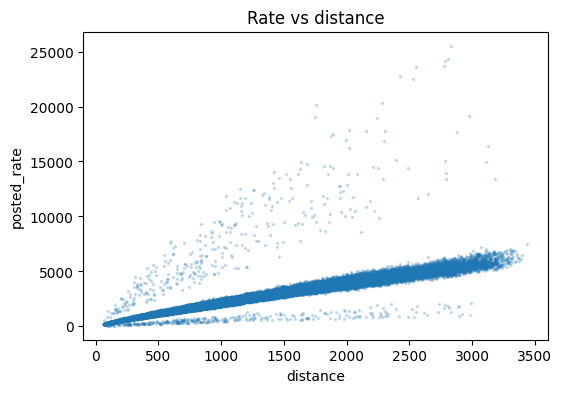

In [10]:
def haversine(lat1, lon1, lat2, lon2):
    p = np.pi / 180
    a = (np.sin((lat2 - lat1) * p / 2) ** 2
         + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin((lon2 - lon1) * p / 2) ** 2)
    return 3958.8 * 2 * np.arcsin(np.sqrt(a))

for d in (train, val):
    d["hav"] = haversine(d.pickup_lat, d.pickup_lon, d.delivery_lat, d.delivery_lon)

print("distance / haversine ratio:")
print((train.distance / train.hav).describe().round(3))

# each city should map to one coordinate pair
print("\nMax distinct coords per pickup city:",
      train.groupby("pickup")[["pickup_lat", "pickup_lon"]].nunique().max().to_dict())

plt.figure(figsize=(6, 4))
plt.scatter(train.distance, train.posted_rate, s=2, alpha=0.2)
plt.xlabel("distance"); plt.ylabel("posted_rate"); plt.title("Rate vs distance"); plt.show()

Cell 6: Equipment, weight, and the signal columns

               n  median_rpm  mean_rate
equipment                              
Dry Van    27202        2.05    2271.55
Flatbed     8753        2.22    2445.09
Reefer     12045        2.31    2553.64

Correlation with rate per mile:
rpm             1.00
quote_signal    0.05
market_index    0.08
weight          0.07
distance       -0.33
Name: rpm, dtype: float64


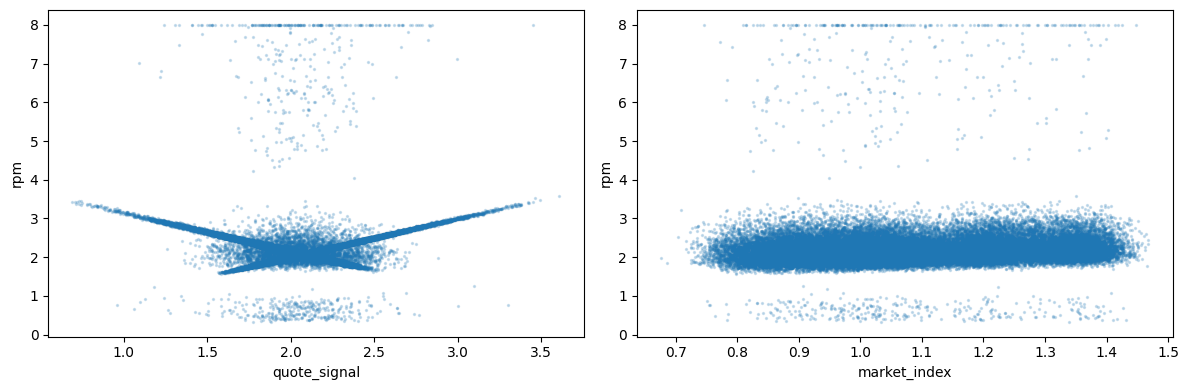

In [11]:
print(train.groupby("equipment").agg(n=("rpm", "size"), median_rpm=("rpm", "median"),
                                      mean_rate=("posted_rate", "mean")).round(2))

print("\nCorrelation with rate per mile:")
print(train[["rpm", "quote_signal", "market_index", "weight", "distance"]]
      .corr().round(2)["rpm"])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(train.quote_signal, train.rpm.clip(upper=8), s=2, alpha=0.2)
ax[0].set_xlabel("quote_signal"); ax[0].set_ylabel("rpm")
ax[1].scatter(train.market_index, train.rpm.clip(upper=8), s=2, alpha=0.2)
ax[1].set_xlabel("market_index"); ax[1].set_ylabel("rpm")
plt.tight_layout(); plt.show()

Cell 7: Time patterns

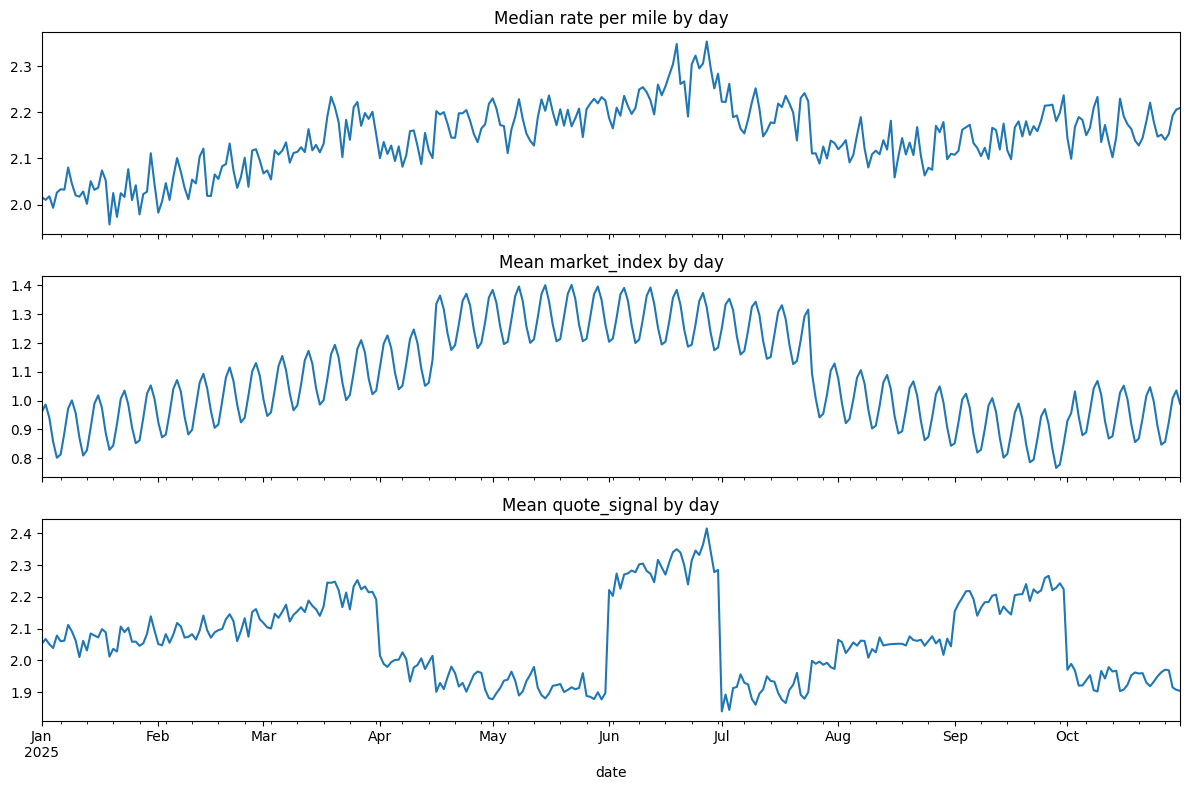

dow
0    2.126
1    2.139
2    2.163
3    2.171
4    2.157
5    2.132
6    2.127
Name: rpm, dtype: float64
date
1     4918
2     4337
3     5036
4     4819
5     4913
6     4783
7     4912
8     4759
9     4670
10    4853
dtype: int64

Within-day std of market_index (avg): 0.0249


In [12]:
daily = train.groupby("date").agg(rpm=("rpm", "median"), mi=("market_index", "mean"),
                                  qs=("quote_signal", "mean"))

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
daily.rpm.plot(ax=ax[0], title="Median rate per mile by day")
daily.mi.plot(ax=ax[1], title="Mean market_index by day")
daily.qs.plot(ax=ax[2], title="Mean quote_signal by day")
plt.tight_layout(); plt.show()

train["dow"] = train.date.dt.dayofweek
print(train.groupby("dow").rpm.median().round(3))
print(train.groupby(train.date.dt.month).size())

# market_index: daily level plus small row-level noise
g = train.groupby("date").market_index.agg(["mean", "std"])
print("\nWithin-day std of market_index (avg):", g["std"].mean().round(4))

Cell 8: Train vs validation shift

In [13]:
train_cities = set(train.pickup) | set(train.delivery)
val_cities = set(val.pickup) | set(val.delivery)
print("Cities only in validation:", sorted(val_cities - train_cities))
print("Rows in val touching an unseen city:",
      (~val.pickup.isin(train_cities) | ~val.delivery.isin(train_cities)).sum())

print("\nEquipment mix (share):")
print(pd.concat([train.equipment.value_counts(normalize=True).rename("train"),
                 val.equipment.value_counts(normalize=True).rename("val")], axis=1).round(3))

num = ["distance", "weight", "market_index", "quote_signal"]
print("\nNumeric feature means:")
print(pd.concat([train[num].mean().rename("train"), val[num].mean().rename("val")], axis=1).round(3))

print("\nMonthly mean market_index / quote_signal in val:")
print(val.groupby(val.date.dt.month)[["market_index", "quote_signal"]].mean().round(3))

Cities only in validation: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
Rows in val touching an unseen city: 1447

Equipment mix (share):
           train    val
equipment              
Dry Van    0.567  0.565
Reefer     0.251  0.254
Flatbed    0.182  0.181

Numeric feature means:
                  train        val
distance       1135.857   1141.773
weight        31028.844  30506.636
market_index      1.083      0.927
quote_signal      2.062      2.051

Monthly mean market_index / quote_signal in val:
      market_index  quote_signal
date                            
11           0.919         2.055
12           0.935         2.048


Cell 9: Cleaning and features

In [14]:
def clean(df, weight_median):
    df = df.copy()
    # weight: negatives are sign errors -> abs(); fill missing; keep flags
    df["weight_neg"] = (df.weight < 0).astype(int)
    df["weight"] = df.weight.abs()
    df["weight_missing"] = df.weight.isna().astype(int)
    df["weight"] = df.weight.fillna(weight_median)

    # market_index: fill with same-day median (interpolate if the whole day is missing)
    df["mi_missing"] = df.market_index.isna().astype(int)
    daily = df.groupby("date").market_index.median()
    daily = daily.reindex(pd.date_range(daily.index.min(), daily.index.max())).interpolate(limit_direction="both")
    df["market_index"] = df.market_index.fillna(df.date.map(daily))
    return df

def haversine(lat1, lon1, lat2, lon2):
    p = np.pi / 180
    a = (np.sin((lat2 - lat1) * p / 2) ** 2
         + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin((lon2 - lon1) * p / 2) ** 2)
    return 3958.8 * 2 * np.arcsin(np.sqrt(a))

def add_features(df):
    df = df.copy()
    df["hav"] = haversine(df.pickup_lat, df.pickup_lon, df.delivery_lat, df.delivery_lon)
    df["log_dist"] = np.log(df.distance)
    df["dow"] = df.date.dt.dayofweek
    df["dom"] = df.date.dt.day
    df["equip"] = df.equipment.map({"Dry Van": 0, "Flatbed": 1, "Reefer": 2})
    return df

FEATURES = ["distance", "log_dist", "hav", "weight", "weight_missing", "market_index",
            "mi_missing", "quote_signal", "pickup_lat", "pickup_lon",
            "delivery_lat", "delivery_lon", "dow", "dom", "equip"]

w_med = train.weight.abs().median()          # computed from train only
tr = add_features(clean(train, w_med))
va = add_features(clean(val, w_med))
tr["rpm"] = tr.posted_rate / tr.distance

print("Remaining NaNs in features (train/val):",
      tr[FEATURES].isna().sum().sum(), va[FEATURES].isna().sum().sum())

Remaining NaNs in features (train/val): 0 0


Cell 10: Time-based split and baseline

In [15]:
from sklearn.metrics import mean_absolute_error

cut = pd.Timestamp("2025-09-01")
fit = tr[tr.date < cut]      # Jan-Aug
hold = tr[tr.date >= cut]    # Sep-Oct (simulates predicting the future)
print("fit rows:", len(fit), "| holdout rows:", len(hold))

def report(name, y, p):
    mae = mean_absolute_error(y, p)
    mape = (np.abs(y - p) / y).mean() * 100
    print(f"{name:<22} MAE = {mae:7.1f}   MAPE = {mape:5.2f}%")

# Baseline: median rate-per-mile by equipment x distance
base_rpm = fit.groupby("equipment").rpm.median()
report("Baseline", hold.posted_rate, hold.equipment.map(base_rpm) * hold.distance)

fit rows: 38477 | holdout rows: 9523
Baseline               MAE =   229.1   MAPE = 10.49%


Cell 11: First LightGBM model

In [16]:
!pip install -q lightgbm
import lightgbm as lgb

def make_model(objective="huber"):
    return lgb.LGBMRegressor(
        n_estimators=600, learning_rate=0.03, num_leaves=31, min_child_samples=40,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        objective=objective, random_state=42, verbose=-1)

for obj in ["l2", "huber"]:
    m = make_model(obj)
    m.fit(fit[FEATURES], np.log(fit.posted_rate))          # model log(rate)
    pred = np.exp(m.predict(hold[FEATURES]))
    report(f"LightGBM ({obj})", hold.posted_rate, pred)

imp = pd.Series(m.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp

LightGBM (l2)          MAE =   150.1   MAPE =  6.43%
LightGBM (huber)       MAE =   148.8   MAPE =  6.36%


,0
quote_signal,2260
weight,2222
market_index,2218
distance,2216
pickup_lat,1318
dom,1281
hav,1243
delivery_lat,1243
delivery_lon,1060
pickup_lon,1056


Cell 12: Expanding-window cross-validation

In [17]:
tr["month"] = tr.date.dt.month

def cv_expanding(make_model, target="rate", months=(6, 7, 8, 9, 10)):
    rows = []
    for k in months:
        f, h = tr[tr.month < k], tr[tr.month == k]
        m = make_model()
        if target == "rate":                      # model log(posted_rate)
            m.fit(f[FEATURES], np.log(f.posted_rate))
            p = np.exp(m.predict(h[FEATURES]))
        else:                                     # model log(rate per mile), then x distance
            m.fit(f[FEATURES], np.log(f.rpm))
            p = np.exp(m.predict(h[FEATURES])) * h.distance
        mae = mean_absolute_error(h.posted_rate, p)
        mape = (np.abs(h.posted_rate - p) / h.posted_rate).mean() * 100
        rows.append({"val_month": k, "train_rows": len(f), "MAE": round(mae, 1), "MAPE_%": round(mape, 2)})
    out = pd.DataFrame(rows)
    print(f"mean MAE = {out.MAE.mean():.1f} | mean MAPE = {out['MAPE_%'].mean():.2f}%")
    return out

print("Target = log(posted_rate)")
display(cv_expanding(lambda: make_model("huber"), "rate"))

print("Target = log(rate per mile)")
display(cv_expanding(lambda: make_model("huber"), "rpm"))

Target = log(posted_rate)
mean MAE = 130.1 | mean MAPE = 5.52%


,val_month,train_rows,MAE,MAPE_%
0,6,24023,140.2,5.09
1,7,28806,106.0,4.44
2,8,33718,121.9,5.86
3,9,38477,153.6,6.17
4,10,43147,128.7,6.02


Target = log(rate per mile)
mean MAE = 129.1 | mean MAPE = 5.52%


,val_month,train_rows,MAE,MAPE_%
0,6,24023,137.6,4.90
1,7,28806,101.7,4.21
2,8,33718,141.5,7.18
3,9,38477,140.0,5.60
4,10,43147,124.7,5.73


Cell 13: Where does the model make its biggest errors?

In [18]:
m = make_model("huber")
m.fit(fit[FEATURES], np.log(fit.posted_rate))
hold = hold.copy()
hold["pred"] = np.exp(m.predict(hold[FEATURES]))
hold["ape"] = (hold.pred - hold.posted_rate).abs() / hold.posted_rate * 100

print("By equipment:");  display(hold.groupby("equipment").ape.mean().round(2))
print("By distance bin:"); display(hold.groupby(pd.cut(hold.distance, [0, 250, 500, 1000, 2000, 4000]), observed=True).ape.agg(["mean", "size"]).round(2))
print("Worst 10 predictions:")
display(hold.sort_values("ape", ascending=False)[["pickup", "delivery", "distance", "equipment", "posted_rate", "pred", "ape"]].head(10).round(1))

By equipment:


,ape
equipment,
Dry Van,6.07
Flatbed,6.91
Reefer,6.61


By distance bin:


,mean,size
distance,,
"(0, 250]",5.91,550
"(250, 500]",6.61,1540
"(500, 1000]",6.84,2972
"(1000, 2000]",5.94,2927
"(2000, 4000]",6.14,1534


Worst 10 predictions:


,pickup,delivery,distance,equipment,posted_rate,pred,ape
45059,Raleigh,Columbia,420.9,Reefer,183.8,1032.1,461.6
46399,Indianapolis,Madison,276.6,Dry Van,123.3,668.0,441.7
45424,Mobile,Boston,1402.1,Flatbed,568.3,3028.7,433.0
38590,Greensboro,Jacksonville,365.7,Flatbed,170.4,877.6,415.1
42032,Kansas City,Baton Rouge,737.8,Reefer,322.3,1645.0,410.3
43704,New York,Austin,1943.2,Reefer,785.3,4003.4,409.8
40173,Salt Lake City,Reno,521.0,Flatbed,244.0,1226.2,402.4
46173,Philadelphia,El Paso,2490.9,Dry Van,880.1,4328.2,391.8
44670,Tampa,Baton Rouge,444.7,Dry Van,200.3,983.7,391.1
47503,Bakersfield,Montgomery,2063.5,Reefer,880.0,4226.9,380.3


Cell 14: Finding the corrupted prices

Rows flagged as corrupted: 677 (1.41%)
Too LOW  (price < 0.74x expected): 337
Too HIGH (price > 1.35x expected): 340
Typical size of normal error: 0.0333


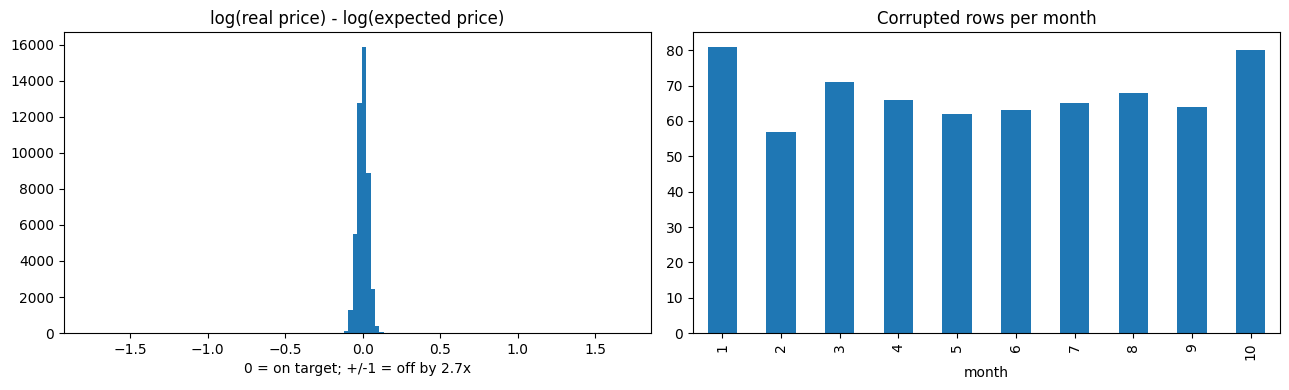

,pickup,delivery,distance,equipment,posted_rate,ratio
50,Los Angeles,Green Bay,2202.5,Reefer,1243.45,0.29
190,Tampa,Milwaukee,919.8,Dry Van,704.89,0.39
294,Greensboro,Syracuse,685.6,Dry Van,518.31,0.37
388,Corpus Christi,Chattanooga,823.0,Flatbed,5485.49,3.08
439,Richmond,Charleston,394.9,Dry Van,276.27,0.34
469,Phoenix,Jacksonville,2154.3,Dry Van,10854.69,2.99
508,Las Vegas,Grand Rapids,1976.4,Flatbed,699.41,0.19
785,Kansas City,Charleston,861.5,Dry Van,4587.83,2.78


In [19]:
import statsmodels.api as sm
import lightgbm as lgb

T0 = pd.Timestamp("2025-01-01")
W_MED = train.weight.abs().median()

def clean(df):
    df = df.copy()
    df["weight"] = df.weight.abs()                      # negative weights -> positive
    df["weight_missing"] = df.weight.isna().astype(int)
    df["weight"] = df.weight.fillna(W_MED)
    df["mi_missing"] = df.market_index.isna().astype(int)
    daily = df.groupby("date").market_index.median()    # fill with that day's median
    daily = daily.reindex(pd.date_range(daily.index.min(), daily.index.max())).interpolate(limit_direction="both")
    df["market_index"] = df.market_index.fillna(df.date.map(daily))
    return df

def add_features(df, daily_dq=None, daily_dm=None):
    d = df.copy()
    d["t"] = (d.date - T0).dt.days                       # days since Jan 1
    d["dq"] = d.date.map(daily_dq) if daily_dq is not None else d.groupby("date").quote_signal.transform("mean")
    d["dm"] = d.date.map(daily_dm) if daily_dm is not None else d.groupby("date").market_index.transform("median")
    d["lm"] = np.log(d.market_index); d["lq"] = np.log(d.quote_signal); d["ldq"] = np.log(d.dq)
    d["ld"] = np.log(d.distance); d["ld2"] = d.ld ** 2; d["lw"] = np.log(d.weight.clip(lower=1))
    d["dom_f"] = d.date.dt.day / 31
    for k in (1, 2):
        d[f"ws{k}"] = np.sin(2 * np.pi * k * d.date.dt.dayofweek / 7)
        d[f"wc{k}"] = np.cos(2 * np.pi * k * d.date.dt.dayofweek / 7)
    d["equip"] = d.equipment.map({"Dry Van": 0, "Flatbed": 1, "Reefer": 2})
    return d

LIN = ["lm", "lq", "ldq", "ld", "ld2", "lw", "t", "dom_f", "ws1", "wc1", "ws2", "wc2"]

def lin_X(d):
    x = pd.get_dummies(d.equipment).astype(float).reindex(columns=["Dry Van", "Flatbed", "Reefer"], fill_value=0)[["Flatbed", "Reefer"]]
    for c in LIN:
        x[c] = d[c]
    return sm.add_constant(x, has_constant="add")

def flag_label_outliers(d, thr=0.3):
    """Fit a simple model, flag rows whose price is far off, refit without them (3 rounds)."""
    keep = np.ones(len(d), bool)
    for _ in range(3):
        r = sm.OLS(np.log(d.posted_rate[keep]), lin_X(d[keep])).fit()
        res = np.log(d.posted_rate) - r.predict(lin_X(d))
        keep = (res.abs() <= thr).values
    return ~keep, res

tr2 = add_features(clean(train))
tr2["month"] = tr2.date.dt.month
is_bad, resid = flag_label_outliers(tr2)
tr2["is_bad"], tr2["resid"] = is_bad, resid

print("Rows flagged as corrupted:", is_bad.sum(), f"({is_bad.mean()*100:.2f}%)")
print("Too LOW  (price < 0.74x expected):", (resid < -0.3).sum())
print("Too HIGH (price > 1.35x expected):", (resid > 0.3).sum())
print("Typical size of normal error:", round(resid[~is_bad].std(), 4))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(resid.clip(-2, 2), bins=120); ax[0].set_title("log(real price) - log(expected price)")
ax[0].set_xlabel("0 = on target; +/-1 = off by 2.7x")
tr2.groupby("month").is_bad.sum().plot.bar(ax=ax[1], title="Corrupted rows per month")
plt.tight_layout(); plt.show()

cols = ["pickup", "delivery", "distance", "equipment", "posted_rate"]
display(tr2[is_bad].assign(ratio=np.exp(resid[is_bad]).round(2))[cols + ["ratio"]].head(8))

Cell 15: Prices drift over time

Average % the price sits above/below the no-trend model, by month:
month
1    -3.24
2    -3.04
3    -0.84
4    -1.21
5     0.21
6     1.23
7     0.90
8     0.27
9     2.61
10    2.97
Name: r0, dtype: float64


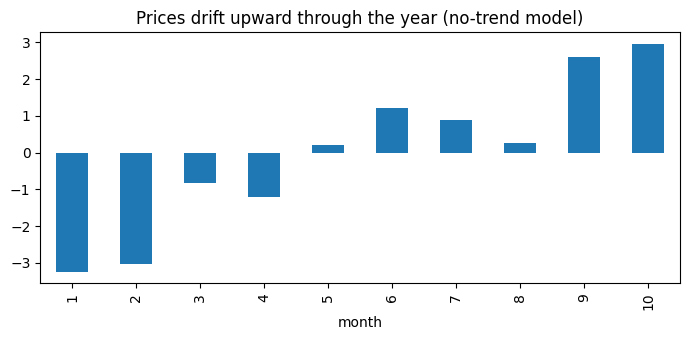


Trend per 30 days: about 0.67 %
Residual std without trend: 0.0388 | with trend + daily signals: 0.0333


In [20]:
c = tr2[~tr2.is_bad]

def X_no_trend(d):
    return lin_X(d).drop(columns=["t", "dom_f", "ws1", "wc1", "ws2", "wc2"])

r0 = sm.OLS(np.log(c.posted_rate), X_no_trend(c)).fit()
c = c.assign(r0=r0.resid)
monthly = c.groupby("month").r0.mean() * 100
print("Average % the price sits above/below the no-trend model, by month:")
print(monthly.round(2))

fig, ax = plt.subplots(figsize=(7, 3.5))
monthly.plot.bar(ax=ax, title="Prices drift upward through the year (no-trend model)")
plt.tight_layout(); plt.show()

r1 = sm.OLS(np.log(c.posted_rate), lin_X(c)).fit()
print("\nTrend per 30 days: about", round((np.exp(r1.params['t'] * 30) - 1) * 100, 2), "%")
print("Residual std without trend:", round(r0.resid.std(), 4),
      "| with trend + daily signals:", round(r1.resid.std(), 4))

Cell 16: The improved model and its five time-based tests

In [21]:
GBM = ["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon", "distance", "weight", "equip",
       "dom_f", "dq", "quote_signal", "market_index"]

def fit_hybrid(d):
    bad, _ = flag_label_outliers(d)
    f = d[~bad]                                   # corrupted prices are excluded from training only
    lin = sm.OLS(np.log(f.posted_rate), lin_X(f)).fit()
    gbm = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=80,
                            subsample=0.8, subsample_freq=1, objective="l2", random_state=42, verbose=-1)
    gbm.fit(f[GBM], np.log(f.posted_rate) - lin.predict(lin_X(f)))   # learns what the line missed
    return lin, gbm

def predict_hybrid(model, d):
    lin, gbm = model
    return np.exp(lin.predict(lin_X(d)) + gbm.predict(d[GBM]))

rows = []
for k in [6, 7, 8, 9, 10]:
    f, h = tr2[tr2.month < k], tr2[tr2.month == k]
    model = fit_hybrid(f)
    p = predict_hybrid(model, h)
    ape = (p - h.posted_rate).abs() / h.posted_rate * 100
    bad_h = h.is_bad.values
    rows.append({"val_month": k, "train_rows": len(f),
                 "MAE": round(mean_absolute_error(h.posted_rate, p), 1),
                 "MAPE_all_%": round(ape.mean(), 2),
                 "MAPE_clean_%": round(ape[~bad_h].mean(), 2)})
cv = pd.DataFrame(rows)
display(cv)
print("AVERAGE  MAE = %.1f | MAPE all = %.2f%% | MAPE clean = %.2f%%" %
      (cv.MAE.mean(), cv["MAPE_all_%"].mean(), cv["MAPE_clean_%"].mean()))

,val_month,train_rows,MAE,MAPE_all_%,MAPE_clean_%
0,6,24023,112.6,4.16,2.12
1,7,28806,97.5,4.00,1.84
2,8,33718,86.8,4.01,1.56
3,9,38477,93.0,3.78,1.74
4,10,43147,97.3,4.59,1.62


AVERAGE  MAE = 97.4 | MAPE all = 4.11% | MAPE clean = 1.78%


Cell 17: Final model and validation_predictions.csv

In [22]:
import os
BASE_DIR = os.path.dirname(DATA_DIR)      # the "Machine Learning Assignment" folder

# Train on ALL labeled data (Jan-Oct), excluding corrupted prices
final_model = fit_hybrid(tr2)
n_bad = int(flag_label_outliers(tr2)[0].sum())
print("Final model trained on", len(tr2) - n_bad, "clean rows (", n_bad, "corrupted rows excluded )")

# Predict every Nov-Dec load
val_clean = clean(val)
val_f = add_features(val_clean)
val_f["pred"] = predict_hybrid(final_model, val_f)

# Fill the template in its original order
template = pd.read_csv(f"{DATA_DIR}/validation_predictions_template.csv")
sub = template[["load_id"]].merge(
    val_f[["load_id", "pred"]].rename(columns={"pred": "predicted_rate"}),
    on="load_id", how="left")

assert list(sub.columns) == ["load_id", "predicted_rate"]
assert len(sub) == 12000 and sub.load_id.is_unique
assert sub.predicted_rate.notna().all() and (sub.predicted_rate > 0).all()

sub.to_csv(f"{BASE_DIR}/validation_predictions.csv", index=False)
print("Saved", f"{BASE_DIR}/validation_predictions.csv", sub.shape)
display(sub.head())

Final model trained on 47323 clean rows ( 677 corrupted rows excluded )
Saved /content/drive/MyDrive/Machine Learning Assignment/validation_predictions.csv (12000, 2)


,load_id,predicted_rate
0,TE-000001,849.986820
1,TE-000002,5103.650131
2,TE-000003,5226.693232
3,TE-000004,4073.033888
4,TE-000005,1878.609266


Cell 18: The December chart predictions

In [24]:
dec = pd.read_csv(f"{DATA_DIR}/december_chart_inputs.csv", parse_dates=["date"])
print(dec.shape); display(dec.head(3))

# The file has only 7 columns, so fill in the rest the model needs
city = pd.concat([
    train[["pickup", "pickup_lat", "pickup_lon"]].set_axis(["city", "lat", "lon"], axis=1),
    train[["delivery", "delivery_lat", "delivery_lon"]].set_axis(["city", "lat", "lon"], axis=1)
]).drop_duplicates("city").set_index("city")

dd = dec.copy()
dd["pickup_lat"] = dd.pickup.map(city.lat);       dd["pickup_lon"] = dd.pickup.map(city.lon)
dd["delivery_lat"] = dd.delivery.map(city.lat);   dd["delivery_lon"] = dd.delivery.map(city.lon)

# Market signals for each December date come from the daily averages in validation.csv
daily_dq = val_clean.groupby("date").quote_signal.mean()
daily_dm = val_clean.groupby("date").market_index.median()
dd["quote_signal"] = dd.date.map(daily_dq)
dd["market_index"] = dd.date.map(daily_dm)
dd["weight_missing"] = 0
dd["mi_missing"] = 0
assert dd[["pickup_lat", "delivery_lat", "quote_signal", "market_index"]].notna().all().all(), "missing city or date info"

dd = add_features(dd, daily_dq, daily_dm)
dec_out = dec.copy()
dec_out["predicted_rate"] = predict_hybrid(final_model, dd).round(2)
dec_out["date"] = dec_out.date.dt.strftime("%Y-%m-%d")
dec_out.to_csv(f"{BASE_DIR}/december_chart_predictions.csv", index=False)
print("Saved december_chart_predictions.csv")
print(dec_out.predicted_rate.describe().round(2))

(31, 7)


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN


Saved december_chart_predictions.csv
count     31.00
mean     835.77
std        5.74
min      823.86
25%      831.69
50%      835.17
75%      839.94
max      845.85
Name: predicted_rate, dtype: float64


Cell 19: Run score.py and see the chart

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: /content/drive/MyDrive/Machine Learning Assignment/scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.
 


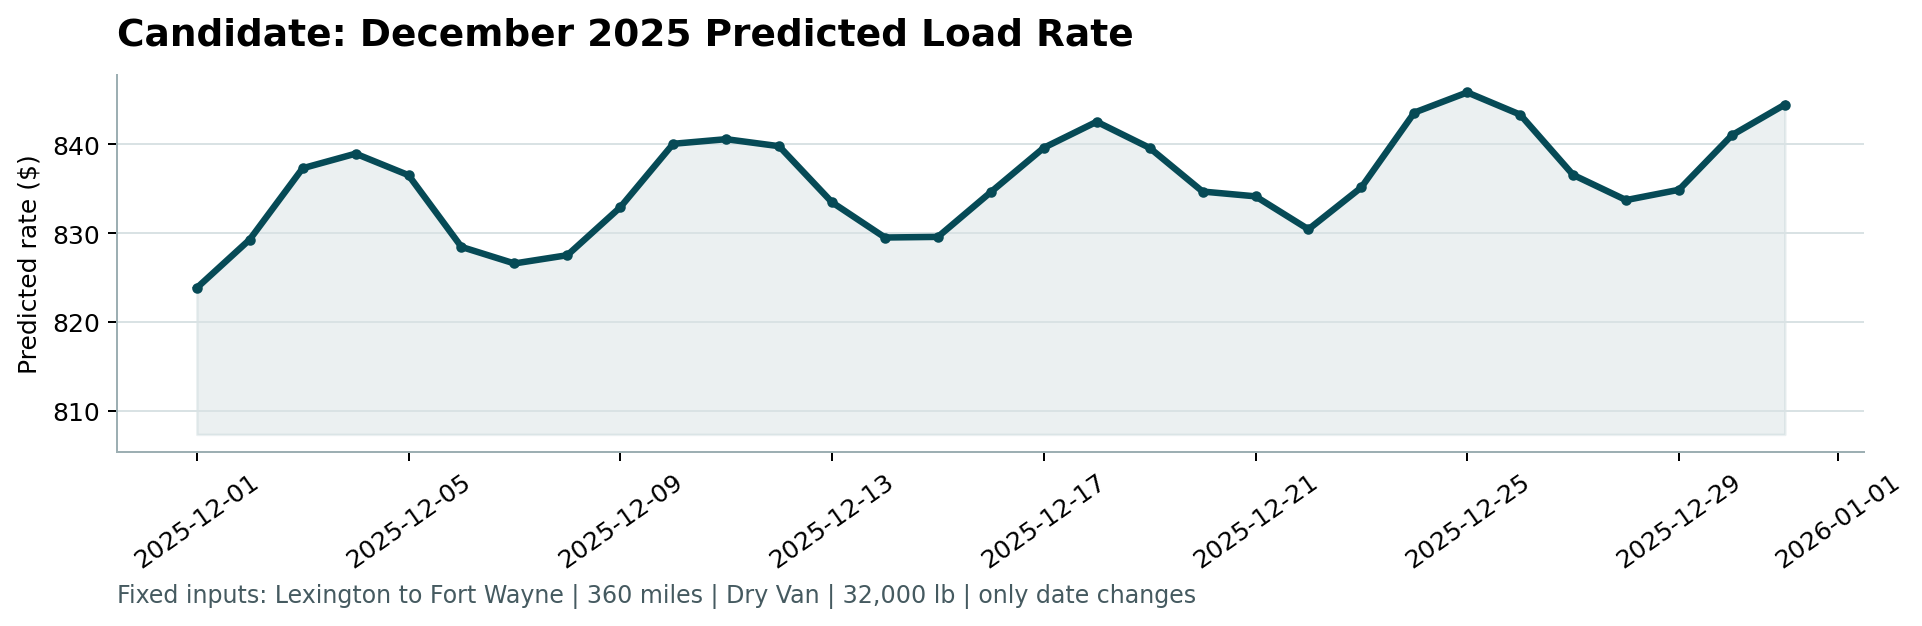

In [25]:
import subprocess
from IPython.display import Image, display as show

res = subprocess.run(["python", f"{BASE_DIR}/score.py",
    "--predictions", f"{BASE_DIR}/validation_predictions.csv",
    "--december-predictions", f"{BASE_DIR}/december_chart_predictions.csv",
    "--output-dir", f"{BASE_DIR}/scorer_results"], capture_output=True, text=True)
print(res.stdout, res.stderr)
show(Image(f"{BASE_DIR}/scorer_results/candidate_december.png"))

Cell 20: Final sanity checks

In [26]:
chk = pd.read_csv(f"{BASE_DIR}/validation_predictions.csv")
print("Columns:", list(chk.columns), "| rows:", len(chk), "| unique ids:", chk.load_id.nunique())
print("Same ids as validation.csv:", set(chk.load_id) == set(val.load_id))
print("Missing / non-positive:", chk.predicted_rate.isna().sum(), (chk.predicted_rate <= 0).sum())

vm = val_f.assign(month=val_f.date.dt.month, ppm=val_f.pred / val_f.distance)
print(vm.groupby("month").agg(avg_pred=("pred", "mean"), median_per_mile=("ppm", "median")).round(2))

tm = tr2[~tr2.is_bad].assign(r=lambda x: x.posted_rate / x.distance).groupby("month").r.median().round(3)
print("Train median $/mile by month:", tm.to_dict())
print("Predictions: min %.0f  median %.0f  max %.0f" %
      (chk.predicted_rate.min(), chk.predicted_rate.median(), chk.predicted_rate.max()))

Columns: ['load_id', 'predicted_rate'] | rows: 12000 | unique ids: 12000
Same ids as validation.csv: True
Missing / non-positive: 0 0
       avg_pred  median_per_mile
month                           
11      2378.62             2.16
12      2387.37             2.18
Train median $/mile by month: {1: 2.029, 2: 2.061, 3: 2.14, 4: 2.147, 5: 2.191, 6: 2.247, 7: 2.187, 8: 2.121, 9: 2.159, 10: 2.164}
Predictions: min 197  median 2060  max 6802
